In [1]:
!git clone https://github.com/anthropics/jacobian-lens.git

fatal: destination path 'jacobian-lens' already exists and is not an empty directory.


In [2]:
cd jacobian-lens

/kaggle/working/jacobian-lens


In [3]:
%pip install -e .

Obtaining file:///kaggle/working/jacobian-lens
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for jlens (pyproject.toml) ... done
  Created wheel for jlens: filename=jlens-0.1.0-0.editable-py3-none-any.whl size=8903 sha256=334352968c1db29acde14808a7893b9c75d41fea592d4343b8d49cd0351ee4e5
  Stored in directory: /tmp/pip-ephem-wheel-cache-q6uf443r/wheels/1c/9b/32/c4a41a0ec872d1d1b4c77a876351e67d3de09dc57eee2c63c5
Successfully built jlens
  Attempting uninstall: jlens
    Found existing installation: jlens 0.1.0
    Uninstalling jlens-0.1.0:
      Successfully uninstalled jlens-0.1.0
Note: you may need to restart the kernel to use updated packages.


In [4]:
# Install a precompiled causal-conv1d wheel matching PyTorch 2.10 / CUDA 12.x
!pip install causal-conv1d --no-build-isolation

In [7]:
%pip install -U git+https://github.com/huggingface/transformers.git
!pip install -U bitsandbytes
%pip install flash-linear-attention

  Cloning https://github.com/huggingface/transformers.git to /tmp/pip-req-build-qn06layu
  Running command git clone --filter=blob:none --quiet https://github.com/huggingface/transformers.git /tmp/pip-req-build-qn06layu
  Resolved https://github.com/huggingface/transformers.git to commit 0df4ef369d324d4072e2910c673671eed4e92459
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


## load the model  and pre fitted lens

In [9]:
import torch
import transformers
import jlens

MODEL_NAME = "Qwen/Qwen3.5-4B"

LENS_REPO = "neuronpedia/jacobian-lens"
LENS_REVISION = "qwen-n1000"
LENS_FILE = "qwen3.5-4b/jlens/Salesforce-wikitext/Qwen3.5-4B_jacobian_lens_n1000.pt"

# 4-bit quantization
quant_config = transformers.BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
)

hf_model = transformers.AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=quant_config,
    device_map="cuda",
)

tokenizer = transformers.AutoTokenizer.from_pretrained(MODEL_NAME)

model = jlens.from_hf(hf_model, tokenizer)

lens = jlens.JacobianLens.from_pretrained(
    LENS_REPO,
    filename=LENS_FILE,
    revision=LENS_REVISION,
)

layers = list(lens.source_layers)

print("Model loaded")
print(f"VRAM allocated: {torch.cuda.memory_allocated()/1024**3:.2f} GB")

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/426 [00:00<?, ?it/s]

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

Model loaded
VRAM allocated: 2.90 GB


## Apply: J-lens vs logit lens

In [10]:
prompt = "Fact: The currency used in the country shaped like a boot is"
layers = [
    model.n_layers // 4,
    model.n_layers // 2,
    model.n_layers // 4 * 3,
    model.n_layers - 2,
]

jlens_logits, model_logits, _ = lens.apply(model, prompt, layers=layers, positions=[-2])
logit_lens, _, _ = lens.apply(
    model, prompt, layers=layers, positions=[-2], use_jacobian=False
)


def top5(logits):
    return [tokenizer.decode([t]) for t in logits.topk(5).indices]


for layer in layers:
    print(f"L{layer:>3} logit-lens: {top5(logit_lens[layer][0])}")
    print(f"L{layer:>3} J-lens:     {top5(jlens_logits[layer][0])}")
print(f"model:           {top5(model_logits[0])}")

L  8 logit-lens: ['长在', 'ולי', 'oman', ' Urlaubs', 'edom']
L  8 J-lens:     [' `', ' Italy', ' italian', ' boots', ' *']
L 16 logit-lens: ['shaw', 'วย', ' overrun', '长在', '举世']
L 16 J-lens:     ['?', ' Italy', '？', "'?", '____']
L 24 logit-lens: ['的形状', '形状的', 'leneck', '😀', '-shaped']
L 24 J-lens:     ['-shaped', ' shape', ' shaped', 'shape', '靴']
L 30 logit-lens: [' is', ' shape', ' heel', '-shaped', ' shaped']
L 30 J-lens:     [' is', ' shape', ' shaped', '-shaped', ' heel']
model:           [' is', ' in', '.', ' on', '?']


## Render a slice page (inline)

In [11]:
import gzip
import json

from jlens.examples import EXAMPLES, resolve_prompt
from jlens.vis import build_page, compute_slice, notebook_iframe

# English gloss for Qwen's Chinese/Japanese/Korean vocab tokens (machine-
# generated, best-effort), shown next to
# the token in the page (alt_token=).
gloss = {
    int(k): v for k, v in json.load(gzip.open("assets/qwen_gloss.json.gz")).items()
}

example = next(e for e in EXAMPLES if e.slug == "multihop")
prompt = resolve_prompt(example, tokenizer)

slice_data = compute_slice(
    model,
    lens,
    prompt,
    layer_stride=2,
    # Empirically on Qwen, the interesting word tokens trail punctuation and
    # single-character tokens in the raw top-K; mask to word-like tokens only.
    mask_display=True,
)
page, _, _ = build_page(
    slice_data,
    prompt,
    title=example.section,
    description=example.description,
    alt_token=gloss,
)
notebook_iframe(page)

## Render a slice page (served)

In [12]:
import os
import threading
from functools import partial
from http.server import HTTPServer, SimpleHTTPRequestHandler
from pathlib import Path

example = next(e for e in EXAMPLES if e.slug == "ascii-face")
prompt = resolve_prompt(example, tokenizer)

slice_data = compute_slice(model, lens, prompt, mask_display=True)
out_dir = Path("slices") / example.slug
page, _, _ = build_page(
    slice_data,
    prompt,
    title=example.section,
    description=example.description,
    alt_token=gloss,
    mode="fetch",
    out_dir=out_dir,
)
(out_dir / "index.html").write_text(page)

if "_jlens_httpd" not in globals():
    _handler = partial(SimpleHTTPRequestHandler, directory=os.path.abspath("slices"))
    _jlens_httpd = HTTPServer(("127.0.0.1", 0), _handler)
    threading.Thread(target=_jlens_httpd.serve_forever, daemon=True).start()
print(f"-> http://localhost:{_jlens_httpd.server_address[1]}/{example.slug}/")

-> http://localhost:35993/ascii-face/


## experiment

In [21]:
import glob
import json
import os

files = glob.glob("data/experiments/**/*", recursive=True)
for f in files:
    print(f)

data/experiments/dual-task.json
data/experiments/directed-modulation.json
data/experiments/flexible-generalization.json
data/experiments/README.md
data/experiments/ignition.json
data/experiments/top-down-summoning.json
data/experiments/selectivity-linecount.json
data/experiments/verbal-introspection.json
data/experiments/verbal-report.json
data/experiments/selectivity-language.json
data/experiments/capacity.json
data/experiments/probe-swap.json


In [26]:
with open("data/experiments/dual-task.json", "r", encoding="utf-8") as f:
    exp = json.load(f)

print("Carrier:", exp["carrier_sentence"])
print("Conditions:", exp["concept_math_conditions"])
print("Pairs:", len(exp["pairs"]))

Carrier: The old painting hung crookedly on the wall.
Conditions: ['concept', 'math', 'concept_first', 'math_first']
Pairs: 21


In [27]:
pair = exp["pairs"][0]

concept = pair["concept"]
concept_words = pair["concept_words"]
carrier = exp["carrier_sentence"]

prompt = f"Concentrate on {concept} while you write the sentence: {carrier}"

print(prompt)

Concentrate on citrus fruits while you write the sentence: The old painting hung crookedly on the wall.


In [28]:
inputs = tokenizer(
    prompt,
    return_tensors="pt"
)

input_ids = inputs["input_ids"].to("cuda")

tokens = [
    tokenizer.decode([x])
    for x in input_ids[0]
]

print("Number of tokens:", len(tokens))

for i, token in enumerate(tokens):
    print(i, repr(token))

Number of tokens: 23
0 'Con'
1 'cent'
2 'rate'
3 ' on'
4 ' citrus'
5 ' fruits'
6 ' while'
7 ' you'
8 ' write'
9 ' the'
10 ' sentence'
11 ':'
12 ' The'
13 ' old'
14 ' painting'
15 ' hung'
16 ' cro'
17 'oked'
18 'ly'
19 ' on'
20 ' the'
21 ' wall'
22 '.'


In [29]:
positions = list(range(len(tokens)))

lens_logits, model_logits, _ = lens.apply(
    model,
    prompt,
    positions=positions,
)

print("Success!")

Success!


Extract top-1 and rank

In [30]:
results = []

for layer, logits in sorted(lens_logits.items()):

    # logits shape should be:
    # [number_of_positions, vocabulary_size]

    for pos_idx, position in enumerate(positions):

        row = logits[pos_idx]

        top1_id = row.argmax().item()
        top1_token = tokenizer.decode([top1_id])

        # Rank of top-1 is 1 by definition.
        # More generally, calculate rank explicitly:
        rank = (row > row[top1_id]).sum().item() + 1

        results.append({
            "position": position,
            "layer": layer,
            "top1_token": top1_token,
            "rank": rank,
        })

len(results)

713

In [34]:
inputs = tokenizer(prompt, return_tensors="pt")

input_ids = inputs["input_ids"]
tokens = [tokenizer.decode([x]) for x in input_ids[0]]

print("Number of tokens:", len(tokens))

for i, token in enumerate(tokens):
    print(i, repr(token))

Number of tokens: 23
0 'Con'
1 'cent'
2 'rate'
3 ' on'
4 ' citrus'
5 ' fruits'
6 ' while'
7 ' you'
8 ' write'
9 ' the'
10 ' sentence'
11 ':'
12 ' The'
13 ' old'
14 ' painting'
15 ' hung'
16 ' cro'
17 'oked'
18 'ly'
19 ' on'
20 ' the'
21 ' wall'
22 '.'


In [36]:
positions = list(range(len(tokens)))

lens_logits, model_logits, _ = lens.apply(
    model,
    prompt,
    positions=positions,
)

for layer, logits in sorted(lens_logits.items()):
    print(layer, logits.shape)

0 torch.Size([23, 248320])
1 torch.Size([23, 248320])
2 torch.Size([23, 248320])
3 torch.Size([23, 248320])
4 torch.Size([23, 248320])
5 torch.Size([23, 248320])
6 torch.Size([23, 248320])
7 torch.Size([23, 248320])
8 torch.Size([23, 248320])
9 torch.Size([23, 248320])
10 torch.Size([23, 248320])
11 torch.Size([23, 248320])
12 torch.Size([23, 248320])
13 torch.Size([23, 248320])
14 torch.Size([23, 248320])
15 torch.Size([23, 248320])
16 torch.Size([23, 248320])
17 torch.Size([23, 248320])
18 torch.Size([23, 248320])
19 torch.Size([23, 248320])
20 torch.Size([23, 248320])
21 torch.Size([23, 248320])
22 torch.Size([23, 248320])
23 torch.Size([23, 248320])
24 torch.Size([23, 248320])
25 torch.Size([23, 248320])
26 torch.Size([23, 248320])
27 torch.Size([23, 248320])
28 torch.Size([23, 248320])
29 torch.Size([23, 248320])
30 torch.Size([23, 248320])


In [38]:
import pandas as pd

results = []

for layer, logits in sorted(lens_logits.items()):
    for pos_idx, position in enumerate(positions):

        row = logits[pos_idx]

        top1_id = row.argmax().item()
        top1_token = tokenizer.decode([top1_id])

        results.append({
            "layer": layer,
            "position": position,
            "token": tokens[position],
            "top1_token": top1_token,
        })

df = pd.DataFrame(results)

In [45]:
prompts = []

carrier = exp["carrier_sentence"]

for pair in exp["pairs"]:
    prompts.append({
        "key": pair["key"],
        "prompt": (
            f"Concentrate on {pair['concept']} "
            f"while you write the sentence: {carrier}"
        ),
        "target_words": pair["concept_words"],
    })

print("Number of prompts:", len(prompts))
print(prompts[0])

Number of prompts: 21
{'key': 'citrus', 'prompt': 'Concentrate on citrus fruits while you write the sentence: The old painting hung crookedly on the wall.', 'target_words': ['orange', 'lemon', 'lime', 'grapefruit', 'tangerine', 'citrus', 'mandarin', 'clementine']}


In [49]:
all_results = []

for i, item in enumerate(prompts):

    print(f"Running {i+1}/{len(prompts)}: {item['key']}")

    inputs = tokenizer(item["prompt"], return_tensors="pt")
    input_ids = inputs["input_ids"]

    tokens = [
        tokenizer.decode([x])
        for x in input_ids[0]
    ]

    positions = list(range(len(tokens)))

    lens_logits, model_logits, _ = lens.apply(
        model,
        item["prompt"],
        positions=positions,
    )

    # Token IDs for all target words
    target_token_ids = {}

    for word in item["target_words"]:
        ids = tokenizer.encode(word, add_special_tokens=False)

        # Keep single-token targets for this analysis
        if len(ids) == 1:
            target_token_ids[word] = ids[0]

    for layer, logits in sorted(lens_logits.items()):

        for pos_idx, position in enumerate(positions):

            row = logits[pos_idx]

            top1_id = row.argmax().item()
            top1_token = tokenizer.decode([top1_id])

            # Find the best-ranked target word
            target_ranks = {}

            for word, token_id in target_token_ids.items():
                rank = (row > row[token_id]).sum().item() + 1
                target_ranks[word] = rank

            if target_ranks:
                best_target_word = min(
                    target_ranks,
                    key=target_ranks.get
                )
                best_target_rank = target_ranks[best_target_word]
            else:
                best_target_word = None
                best_target_rank = None

            all_results.append({
                "prompt_id": item["key"],
                "layer": layer,
                "position": position,
                "source_token": tokens[position],
                "top1_token": top1_token,
                "best_target_word": best_target_word,
                "target_rank": best_target_rank,
                "hit_at_5": (
                    best_target_rank <= 5
                    if best_target_rank is not None
                    else False
                ),
            })

    del lens_logits, model_logits
    torch.cuda.empty_cache()

df_all = pd.DataFrame(all_results)

print(df_all.shape)
df_all.head()

Running 1/21: citrus
Running 2/21: planets
Running 3/21: instruments
Running 4/21: farm
Running 5/21: months
Running 6/21: days
Running 7/21: chess
Running 8/21: metals
Running 9/21: gems
Running 10/21: weather
Running 11/21: body
Running 12/21: vegetables
Running 13/21: cards
Running 14/21: ocean
Running 15/21: trees
Running 16/21: kitchen
Running 17/21: emotions
Running 18/21: boats
Running 19/21: insects
Running 20/21: desserts
Running 21/21: footwear
(15066, 8)


,prompt_id,layer,position,source_token,top1_token,best_target_word,target_rank,hit_at_5
0,citrus,0,0,Con,er,lime,8854.0,False
1,citrus,0,1,cent,­,lime,2199.0,False
2,citrus,0,2,rate,–,orange,755.0,False
3,citrus,0,3,on,...,orange,85684.0,False
4,citrus,0,4,citrus,\n\n\n\n\n\n\n,lime,242.0,False


In [50]:
layer_summary = (
    df_all
    .groupby("layer")
    .agg(
        prompts=("prompt_id", "nunique"),
        positions=("position", "nunique"),
        observations=("target_rank", "size"),
        mean_target_rank=("target_rank", "mean"),
        median_target_rank=("target_rank", "median"),
        hit_at_5=("hit_at_5", "mean"),
    )
    .reset_index()
)

layer_summary["hit_at_5_pct"] = (
    layer_summary["hit_at_5"] * 100
)

layer_summary = layer_summary.drop(columns="hit_at_5")

layer_summary

,layer,prompts,positions,observations,mean_target_rank,median_target_rank,hit_at_5_pct
0,0,21,25,486,45583.790497,23507.0,0.000000
1,1,21,25,486,50669.885529,30144.0,0.000000
2,2,21,25,486,27137.207343,11183.0,0.000000
3,3,21,25,486,49506.181425,29371.0,0.000000
4,4,21,25,486,32949.993521,16519.0,0.000000
5,5,21,25,486,38053.192225,22080.0,0.000000
6,6,21,25,486,34292.911447,19210.0,0.000000
7,7,21,25,486,34378.127430,18564.0,0.000000
8,8,21,25,486,34126.924406,19278.0,0.205761
9,9,21,25,486,35312.457883,20232.0,0.205761


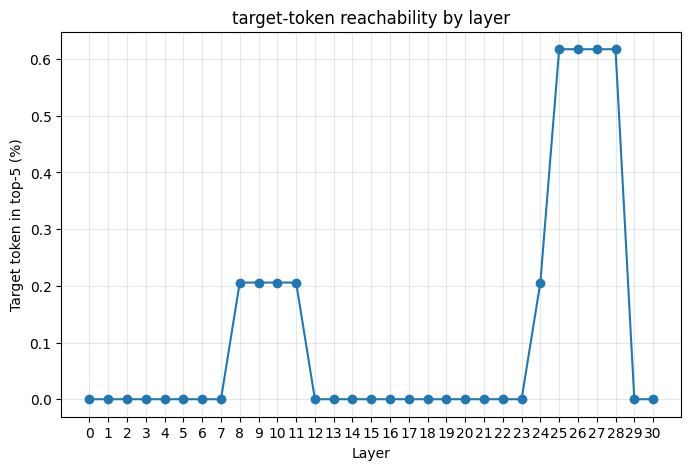

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    layer_summary["layer"],
    layer_summary["hit_at_5_pct"],
    marker="o"
)

plt.xlabel("Layer")
plt.ylabel("Target token in top-5 (%)")
plt.title("target-token reachability by layer")
plt.xticks(layer_summary["layer"])
plt.grid(alpha=0.3)

plt.show()

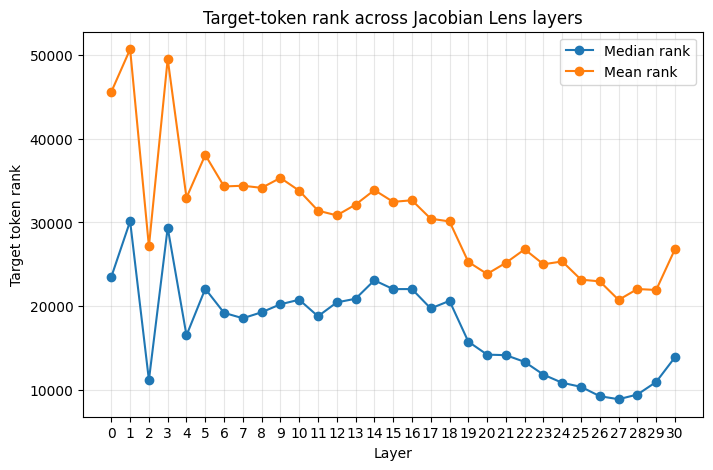

In [53]:
plt.figure(figsize=(8, 5))

plt.plot(
    layer_summary["layer"],
    layer_summary["median_target_rank"],
    marker="o",
    label="Median rank"
)

plt.plot(
    layer_summary["layer"],
    layer_summary["mean_target_rank"],
    marker="o",
    label="Mean rank"
)

plt.xlabel("Layer")
plt.ylabel("Target token rank")
plt.title("Target-token rank across Jacobian Lens layers")
plt.xticks(layer_summary["layer"])
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [55]:
print("Best layer by target reachability:")
print(
    layer_summary.loc[
        layer_summary["hit_at_5_pct"].idxmax()
    ]
)

print("\nBest layer by median target rank:")
print(
    layer_summary.loc[
        layer_summary["median_target_rank"].idxmin()
    ]
)

Best layer by target reachability:
layer                    25.000000
prompts                  21.000000
positions                25.000000
observations            486.000000
mean_target_rank      23170.725702
median_target_rank    10380.000000
hit_at_5_pct              0.617284
Name: 25, dtype: float64

Best layer by median target rank:
layer                    27.000000
prompts                  21.000000
positions                25.000000
observations            486.000000
mean_target_rank      20752.246220
median_target_rank     8901.000000
hit_at_5_pct              0.617284
Name: 27, dtype: float64
